<a href="https://colab.research.google.com/github/tharushidambarage/BioLens-AI-Facial-Analyzer/blob/notebooks/02_Train_EfficientNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 02 — EfficientNet-B0 Transfer Learning & Fine Tuning

This notebook trains the BioLens facial attribute classifier using PyTorch.

**Tasks**

- Hair Colour Classification
- Eyeglasses Classification

**Model**

- EfficientNet-B0 (ImageNet pretrained)
- Transfer Learning
- Fine Tuning

In [2]:
# Mount Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Define Project Paths

In [5]:
import os

BASE_PATH = "/content/drive/MyDrive/BioLens"

DATASET_PATH = os.path.join(BASE_PATH, "datasets", "celeba_subset")
IMAGE_PATH = os.path.join(DATASET_PATH, "images")

MODEL_PATH = os.path.join(BASE_PATH, "models")
OUTPUT_PATH = os.path.join(BASE_PATH, "outputs")

os.makedirs(MODEL_PATH, exist_ok=True)
os.makedirs(OUTPUT_PATH, exist_ok=True)

print(BASE_PATH)

/content/drive/MyDrive/BioLens


In [6]:
!pip install -q torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 53.6 MB/s eta 0:00:00


In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.models import efficientnet_b0
from torchvision.models import EfficientNet_B0_Weights

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from tqdm import tqdm

**Load Train/Validation/Test CSVs**

In [8]:
# Read CSV Files

In [9]:
train_df = pd.read_csv(os.path.join(DATASET_PATH,"train.csv"))
val_df = pd.read_csv(os.path.join(DATASET_PATH,"val.csv"))
test_df = pd.read_csv(os.path.join(DATASET_PATH,"test.csv"))

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(3500, 3)
(750, 3)
(750, 3)


In [10]:
# Encode Labels

In [11]:
hair_encoder = LabelEncoder()

train_df["hair_label"] = hair_encoder.fit_transform(train_df["hair_color"])

val_df["hair_label"] = hair_encoder.transform(val_df["hair_color"])

test_df["hair_label"] = hair_encoder.transform(test_df["hair_color"])

print(hair_encoder.classes_)

['Black' 'Blond' 'Brown']


**Data Augmentation**

In [12]:
# Image Transformation

In [13]:
weights = EfficientNet_B0_Weights.DEFAULT

train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),

    transforms.ToTensor(),

    weights.transforms()

])

val_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    weights.transforms()

])

**Create Custom PyTorch Dataset**

In [14]:
# Dataset Class

In [15]:
class BioLensDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):

        row = self.df.iloc[index]

        img = Image.open(
            os.path.join(
                IMAGE_PATH,
                row.image_id
            )
        ).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, row.hair_label

In [16]:
# Create Dataset Objects

In [17]:
train_dataset = BioLensDataset(train_df, train_transform)

val_dataset = BioLensDataset(val_df, val_transform)

test_dataset = BioLensDataset(test_df, val_transform)

In [18]:
# DataLoaders

In [22]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0      # IMPORTANT in Colab
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

In [23]:
# Verify One Batch

In [24]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


# **Load pretrained Efficientnet-BO**

Explain Transfer Learning.

In [25]:
# Load Model

weights = EfficientNet_B0_Weights.DEFAULT

model = efficientnet_b0(weights=weights)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 72.3MB/s]


In [26]:
# Replace Clasification Layer

num_features = model.classifier[1].in_features

model.classifier[1] = nn.Linear(
    num_features,
    3
)

model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

# **Transfer Learning**

In [27]:
# Freeze Feature Extractor

# Explain: ImageNet features kept, Only classifier learns.

In [28]:
for param in model.features.parameters():
    param.requires_grad = False

In [29]:
# Check Trainable Parameters

trainable = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

total = sum(
    p.numel()
    for p in model.parameters()
)

print("Trainable:", trainable)
print("Total:", total)

Trainable: 3843
Total: 4011391


# **Fine Tuning**

Explain Fine Tuning.

In [30]:
# Unfreeze Last Two Blocks

In [31]:
for param in model.features[-2:].parameters():
    param.requires_grad = True

In [32]:
# Device

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)

print(device)

cuda


In [33]:
# Loss & Optimizer

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    factor=0.5,
    patience=2
)

# **Training Loop**

This is the biggest cell in the notebook.

It will:

Train for 10 epochs.

Compute train loss.

Compute validation loss.

Compute validation accuracy.

Save best model.

In [38]:
# Training Function

In [39]:
from tqdm import tqdm
import torch

def train_model(model):

    EPOCHS = 10
    best_accuracy = 0

    train_loss_history = []
    val_loss_history = []
    val_accuracy_history = []

    for epoch in range(EPOCHS):

        print(f"\nEpoch {epoch+1}/{EPOCHS}")
        print("-"*30)

        # ----------------------
        # Training
        # ----------------------
        model.train()

        running_loss = 0

        for images, labels in tqdm(train_loader):

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        train_loss_history.append(train_loss)

        # ----------------------
        # Validation
        # ----------------------
        model.eval()

        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                val_loss += loss.item()

                predictions = outputs.argmax(dim=1)

                correct += (predictions == labels).sum().item()
                total += labels.size(0)

        val_loss = val_loss / len(val_loader)
        val_accuracy = 100 * correct / total

        val_loss_history.append(val_loss)
        val_accuracy_history.append(val_accuracy)

        scheduler.step(val_loss)

        print(f"Train Loss      : {train_loss:.4f}")
        print(f"Validation Loss : {val_loss:.4f}")
        print(f"Validation Acc. : {val_accuracy:.2f}%")

        # Save best model
        if val_accuracy > best_accuracy:

            best_accuracy = val_accuracy

            torch.save(
                model.state_dict(),
                os.path.join(MODEL_PATH, "best_model.pt")
            )

            print("✅ Best model saved.")

    history = {
        "train_loss": train_loss_history,
        "val_loss": val_loss_history,
        "val_accuracy": val_accuracy_history
    }

    return history

In [41]:
# Start Training

history = train_model(model)


Epoch 1/10
------------------------------


100%|██████████| 110/110 [00:33<00:00,  3.32it/s]


Train Loss      : 0.2301
Validation Loss : 0.3336
Validation Acc. : 87.20%
✅ Best model saved.

Epoch 2/10
------------------------------


100%|██████████| 110/110 [00:33<00:00,  3.29it/s]


Train Loss      : 0.2285
Validation Loss : 0.3427
Validation Acc. : 88.53%
✅ Best model saved.

Epoch 3/10
------------------------------


...

Train Loss      : 0.2096
Validation Loss : 0.3361
Validation Acc. : 88.13%

Epoch 9/10
------------------------------


100%|██████████| 110/110 [00:34<00:00,  3.21it/s]


Train Loss      : 0.2129
Validation Loss : 0.3318
Validation Acc. : 88.40%

Epoch 10/10
------------------------------


100%|██████████| 110/110 [00:33<00:00,  3.26it/s]


Train Loss      : 0.2172
Validation Loss : 0.3381
Validation Acc. : 88.40%


#Evaluation of Model

In [42]:
#load best model
model.load_state_dict(
    torch.load(
        os.path.join(MODEL_PATH,"best_model.pt")
    )
)

<All keys matched successfully>

In [43]:
#test accuracy
model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [47]:
from tqdm import tqdm
import torch
import os

def train_model(model, train_loader, val_loader,
                criterion, optimizer, scheduler,
                device, model_path, epochs=10):

    best_acc = 0
    patience = 3
    wait = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(epochs):

        print(f"\nEpoch {epoch+1}/{epochs}")
        print("-"*40)

        # -------- TRAIN --------
        model.train()
        running_loss = 0

        progress = tqdm(train_loader)

        for images, labels in progress:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            progress.set_postfix(loss=loss.item())

        train_loss = running_loss / len(train_loader)

        # -------- VALIDATION --------
        model.eval()

        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                val_loss += loss.item()

                preds = outputs.argmax(dim=1)

                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss /= len(val_loader)
        val_acc = 100 * correct / total

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Train Loss      : {train_loss:.4f}")
        print(f"Validation Loss : {val_loss:.4f}")
        print(f"Validation Acc. : {val_acc:.2f}%")

        # Save best model
        if val_acc > best_acc:

            best_acc = val_acc
            wait = 0

            torch.save(
                model.state_dict(),
                os.path.join(model_path, "best_model.pt")
            )

            print("✅ Best model saved.")

        else:
            wait += 1

        if wait >= patience:
            print("🛑 Early stopping triggered.")
            break

    print(f"\nBest Validation Accuracy: {best_acc:.2f}%")

    return history

In [48]:
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    model_path=MODEL_PATH,
    epochs=10
)


Epoch 1/10
----------------------------------------


100%|██████████| 110/110 [00:33<00:00,  3.26it/s, loss=0.674]


Train Loss      : 0.2216
Validation Loss : 0.3444
Validation Acc. : 88.27%
✅ Best model saved.

Epoch 2/10
----------------------------------------


100%|██████████| 110/110 [00:34<00:00,  3.19it/s, loss=0.429]


Train Loss      : 0.2175
Validation Loss : 0.3430
Validation Acc. : 88.67%
✅ Best model saved.

Epoch 3/10
----------------------------------------


...

Train Loss      : 0.2110
Validation Loss : 0.3372
Validation Acc. : 88.27%

Epoch 4/10
----------------------------------------


100%|██████████| 110/110 [00:34<00:00,  3.22it/s, loss=0.202]


Train Loss      : 0.2102
Validation Loss : 0.3393
Validation Acc. : 87.73%

Epoch 5/10
----------------------------------------


100%|██████████| 110/110 [00:34<00:00,  3.17it/s, loss=0.192]


Train Loss      : 0.2230
Validation Loss : 0.3407
Validation Acc. : 88.27%
🛑 Early stopping triggered.

Best Validation Accuracy: 88.67%


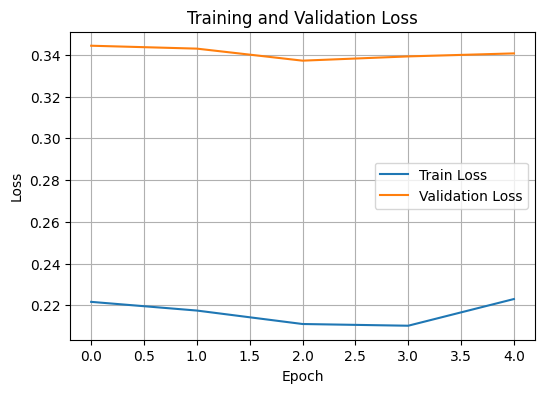

In [49]:
plt.figure(figsize=(6,4))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(OUTPUT_PATH, "loss_curve.png"), dpi=300)
plt.show()

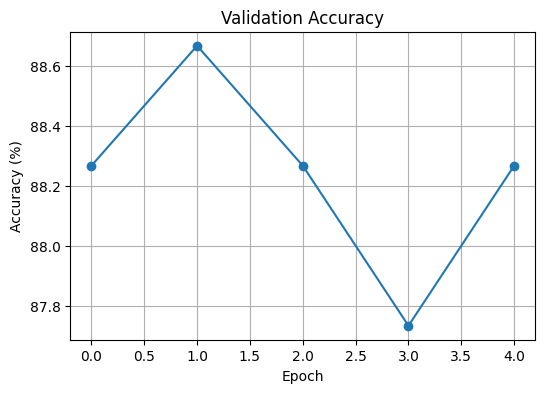

In [50]:
plt.figure(figsize=(6,4))
plt.plot(history["val_acc"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Validation Accuracy")
plt.grid(True)
plt.savefig(os.path.join(OUTPUT_PATH, "accuracy_curve.png"), dpi=300)
plt.show()